In [13]:
from ultralytics import YOLO
model = YOLO("yolov8s.pt")
model.train(data="data.yaml", epochs=100, imgsz=416, batch=32, workers=8, seed=1, project="runs_orig", name="yolov8s_e100_640")

New https://pypi.org/project/ultralytics/8.3.231 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.224  Python-3.10.18 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_e100_64041, nbs=64, nms=False, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000021E05381E10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [14]:
model.val(data="data.yaml", imgsz=416, split="test")

Ultralytics 8.3.224  Python-3.10.18 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 353.3259.3 MB/s, size: 18.8 KB)
val: Scanning E:\a\MCS-Research-Procject\code\dataset\test\labels.cache... 821 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 821/821 820.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 14.3it/s 3.6s0.1s
                   all        821        985      0.894      0.853      0.924      0.662
Speed: 0.3ms preprocess, 0.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to E:\a\MCS-Research-Procject\code\detection\runs\detect\val345


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000021D15DC0130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# few-shot 设置
shots = [10, 30, 80]

# 原始数据
mAP_original = [
    0.446,  # 10-shot original
    0.538,  # 30-shot original
    0.649,  # 80-shot original
]

mAP_mixed = [
    0.53,   # 10-shot mixed
    0.581,  # 30-shot mixed
    0.675,  # 80-shot mixed
]

x = np.arange(len(shots))       # 位置索引：0,1,2
width = 0.35                    # 每个柱子的宽度

plt.figure(figsize=(6, 4))
fig, ax = plt.subplots()

# 画两组柱子：原始 vs mixed
rects1 = ax.bar(x - width/2, mAP_original, width, label='Original')
rects2 = ax.bar(x + width/2, mAP_mixed,    width, label='Mixed')

# 坐标轴和标题
ax.set_xlabel('Number of Shots')
ax.set_ylabel('mAP')
ax.set_title('mAP Comparison: Original vs Mixed Dataset')
ax.set_xticks(x)
ax.set_xticklabels(shots)
ax.legend()

# 在柱子上方标出数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 上移 3 像素
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()

# ① 保存到本地文件（一定会有）
plt.savefig("map_bar.png", dpi=300, bbox_inches="tight")

# ② 如果有图形界面，还会弹出窗口
plt.show()


<Figure size 600x400 with 0 Axes>

<Figure size 640x480 with 1 Axes>

found 102 score files
rows: 816
             clip        dino  bbox_clip_mean
count  816.000000  816.000000      816.000000
mean     0.786002    0.723227        0.273380
std      0.097533    0.199528        0.030736
min      0.515870   -0.009916        0.201379
25%      0.723851    0.690597        0.249553
50%      0.801978    0.799122        0.274316
75%      0.863451    0.852363        0.301364
max      0.960502    0.928112        0.336628

correlation:
                     clip      dino  bbox_clip_mean
clip            1.000000  0.712851        0.639253
dino            0.712851  1.000000        0.595857
bbox_clip_mean  0.639253  0.595857        1.000000


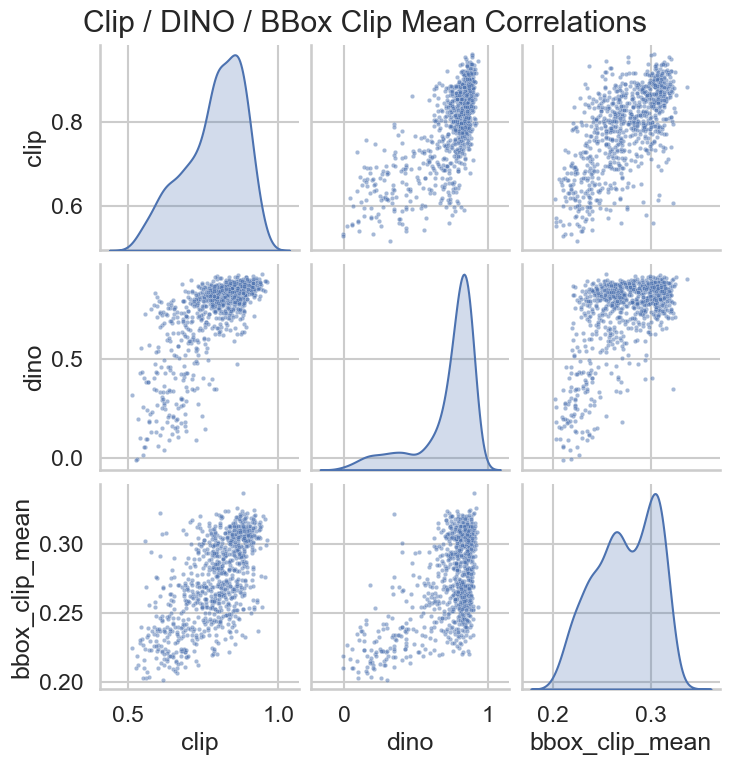

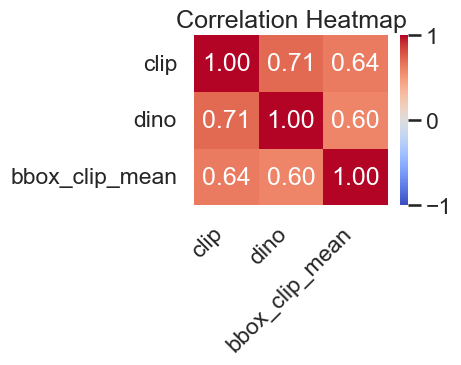

In [21]:
import json
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 配置：根目录指向包含 train/valid/test 等 split 的目录
ROOT = Path("../dataset")  # 按需修改
SCORE_FILES = list((ROOT).glob("*/synth/*/scores.json"))
print(f"found {len(SCORE_FILES)} score files")

rows = []
for sj in SCORE_FILES:
    try:
        data = json.loads(sj.read_text(encoding="utf-8"))
    except Exception as e:
        print("skip", sj, e)
        continue
    for item in data.get("items", []):
        clip = float(item.get("clip_score", 0.0))
        dino = float(item.get("dino_score", 0.0))
        bboxes = item.get("bboxes") or []
        bbox_scores = [float(b.get("clip_score", 0.0)) for b in bboxes]
        bbox_mean = sum(bbox_scores) / len(bbox_scores) if bbox_scores else 0.0
        rows.append({
            "split": sj.parts[-4],   # train / valid / test
            "image_id": sj.parent.name,
            "index": item.get("index", 0),
            "clip": clip,
            "dino": dino,
            "bbox_clip_mean": bbox_mean,
        })

df = pd.DataFrame(rows)
print("rows:", len(df))
print(df[["clip","dino","bbox_clip_mean"]].describe())

# 相关系数
corr = df[["clip","dino","bbox_clip_mean"]].corr()
print("\ncorrelation:\n", corr)

# 可视化
sns.set_theme(context="talk", style="whitegrid")

# 散点 + KDE
g = sns.pairplot(df, vars=["clip","dino","bbox_clip_mean"], kind="scatter",
                 diag_kind="kde", plot_kws={"s": 10, "alpha": 0.5})
g.fig.suptitle("Clip / DINO / BBox Clip Mean Correlations", y=1.02)
plt.show()

# 相关性热力图
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha="right")  # 或 ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()
